# 🔬 스마트팜 펌프 — AE 이상 탐지 & 종합 가설 검증 (v2)

## 🔴 v1 대비 수정된 버그 4가지

| # | 버그 | v1 | v2 수정 |
|---|---|---|---|
| 1 | 임계값 근거 없음 | 퍼센타일 고정 (항상 5% 이상) | **IQR 기반** (데이터 분포 반영) |
| 2 | 정의식 오염 | zone1_resistance AE에 분자·분모 포함 | **AE 입력에서 제외**, 통계 검정만 사용 |
| 3 | Bonferroni 없음 | 다중 검정 보정 누락 | **0.05 / n_tests 적용** |
| 4 | 학습/검증 혼용 | 전체 MSE로 임계값 설정 | **Train MSE로만 임계값 계산** |

## 전체 흐름
```
Part 0 : 모델 I/O 문서
Part 1 : 원시 데이터 EDA  (정규성 / 상관 / KS drift)
Part 2 : AE 학습 (버그 수정)  →  IQR 임계값  →  4단계 알람
Part 3 : 가설 검증  (t-test / Mann-Whitney / Kruskal-Wallis / 카이제곱 / KS drift)
Part 4 : 최종 요약 테이블
```

In [1]:
import subprocess, sys
for pkg in ["pandas","numpy","matplotlib","seaborn","scipy","scikit-learn","tensorflow"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], capture_output=True)
print("설치 완료")

설치 완료


In [2]:
import os, platform, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (mannwhitneyu, shapiro, ks_2samp, kstest,
                          ttest_ind, kruskal, chi2_contingency,
                          spearmanr, pearsonr, probplot)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
np.random.seed(42); tf.random.set_seed(42)

if platform.system() == "Darwin":    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows": plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
print("임포트 완료")

임포트 완료


In [10]:
DATA_PATH = "C:/Users/ui203/OneDrive/문서/green_project/human_A/src/selected_smartfarm.csv"
df_raw = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)

df = df_raw.copy()
eps = 1e-6

# 파생변수 계산
df["zone1_resistance"] = df["zone1_pressure_kpa"] / (df["zone1_flow_l_min"].abs() + eps)
hydraulic = (df["discharge_pressure_kpa"] - df["suction_pressure_kpa"]) * df["flow_rate_l_min"] / 60000
df["wire_to_water_efficiency"] = hydraulic / (df["motor_power_kw"].abs() + eps)
df["zone1_resistance"] = df["zone1_resistance"].clip(upper=df["zone1_resistance"].quantile(0.999))
df["wire_to_water_efficiency"] = df["wire_to_water_efficiency"].clip(0, 2)

# 펌프 가동 구간 필터
df_active = df[df["pump_rpm"] > 0].copy().reset_index(drop=True)
num_cols = df_active.select_dtypes(include=np.number).columns
df_active[num_cols] = df_active[num_cols].fillna(df_active[num_cols].median())

print(f"전체: {len(df):,}행  /  펌프 가동: {len(df_active):,}행")

# 왜도 확인 -> IQR 방법 선택 근거
print()
print("타겟 왜도 (|skew| > 1 이면 IQR 방법이 더 적합)")
for col in ["motor_current_a","zone1_resistance","wire_to_water_efficiency","mix_ph"]:
    s = df_active[col].skew()
    flag = "<- 비정규, IQR 필수" if abs(s) > 1 else "<- 정규에 가까움"
    print(f"  {col:<30} skew={s:7.2f}  {flag}")

전체: 129,591행  /  펌프 가동: 111,893행

타겟 왜도 (|skew| > 1 이면 IQR 방법이 더 적합)
  motor_current_a                skew=  -0.13  <- 정규에 가까움
  zone1_resistance               skew=  14.38  <- 비정규, IQR 필수
  wire_to_water_efficiency       skew=  31.49  <- 비정규, IQR 필수
  mix_ph                         skew=  -0.03  <- 정규에 가까움


In [11]:
# [BUG FIX 2] AE 입력과 통계 검정 피처를 분리
# zone1_resistance AE 입력에서 분자/분모 제거 (정의식 오염 방지)

TARGET_DICTIONARY = {
    "motor_current_a"         : ["motor_temperature_c","pump_rpm","discharge_pressure_kpa"],
    "zone1_resistance"        : ["zone1_pressure_kpa","zone1_flow_l_min"],   # 통계 검정용
    "wire_to_water_efficiency": ["pump_rpm","motor_temperature_c","suction_pressure_kpa","bearing_temperature_c"],
    "mix_ph"                  : ["dosing_acid_ml_min","mix_temp_c","acid_tank_level_pct","mix_flow_l_min"],
}

# AE 입력 피처 (정의식 성분 제거)
AE_INPUT = {
    "motor_current_a"         : ["motor_current_a","motor_temperature_c","pump_rpm","discharge_pressure_kpa"],
    "zone1_resistance"        : ["zone1_resistance","pump_rpm","discharge_pressure_kpa","motor_current_a"],
    "wire_to_water_efficiency": ["wire_to_water_efficiency","pump_rpm","motor_temperature_c","suction_pressure_kpa","bearing_temperature_c"],
    "mix_ph"                  : ["mix_ph","dosing_acid_ml_min","mix_temp_c","acid_tank_level_pct","mix_flow_l_min"],
}

print("AE 입력 피처 (정의식 오염 없는 버전):")
for t, cols in AE_INPUT.items():
    print(f"  [{t}]  {cols}")

AE 입력 피처 (정의식 오염 없는 버전):
  [motor_current_a]  ['motor_current_a', 'motor_temperature_c', 'pump_rpm', 'discharge_pressure_kpa']
  [zone1_resistance]  ['zone1_resistance', 'pump_rpm', 'discharge_pressure_kpa', 'motor_current_a']
  [wire_to_water_efficiency]  ['wire_to_water_efficiency', 'pump_rpm', 'motor_temperature_c', 'suction_pressure_kpa', 'bearing_temperature_c']
  [mix_ph]  ['mix_ph', 'dosing_acid_ml_min', 'mix_temp_c', 'acid_tank_level_pct', 'mix_flow_l_min']


---
## Part 0 — 모델 입출력 명세

In [12]:
COL_DESC = {
    "motor_current_a":"모터 전류(A)","motor_temperature_c":"모터 온도(°C)",
    "pump_rpm":"펌프 RPM","discharge_pressure_kpa":"토출 압력(kPa)",
    "zone1_resistance":"1구역 저항(파생)","zone1_pressure_kpa":"1구역 압력(kPa)",
    "zone1_flow_l_min":"1구역 유량(L/min)","wire_to_water_efficiency":"W2W 효율(파생)",
    "suction_pressure_kpa":"흡입 압력(kPa)","bearing_temperature_c":"베어링 온도(°C)",
    "mix_ph":"실제 pH","dosing_acid_ml_min":"산성액 주입량(mL/min)",
    "mix_temp_c":"양액 온도(°C)","acid_tank_level_pct":"산도 탱크 잔량(%)",
    "mix_flow_l_min":"혼합 유량(L/min)",
}

rows = []
for target, ae_cols in AE_INPUT.items():
    stat_feats = TARGET_DICTIONARY[target]
    for col in ae_cols:
        rows.append({"AE모델":target,"AE입력":"O","통계검정":"O" if col in [target]+stat_feats else "-",
                     "컬럼":col,"타입":"float64","중앙값":round(df_active[col].median(),4),
                     "설명":COL_DESC.get(col,"-")})
    for col in stat_feats:
        if col not in ae_cols:
            rows.append({"AE모델":target,"AE입력":"X (정의식)","통계검정":"O",
                         "컬럼":col,"타입":"float64","중앙값":round(df_active[col].median(),4),
                         "설명":COL_DESC.get(col,"-")})

io_df = pd.DataFrame(rows)
print(io_df.to_string(index=False))

print()
print("출력 명세:")
out_spec = pd.DataFrame([
    {"항목":"mse_score","타입":"float64","설명":"AE 재건 오차 (높을수록 이상)"},
    {"항목":"alarm_level","타입":"int (0~3)","설명":"0=정상|1=주의(Q3+IQR)|2=경고(Q3+1.5IQR)|3=위험(Q3+3IQR)"},
    {"항목":"is_anomaly","타입":"bool","설명":"alarm_level >= 2 (경고 이상)"},
])
print(out_spec.to_string(index=False))

                    AE모델    AE입력 통계검정                       컬럼      타입       중앙값              설명
         motor_current_a       O    O          motor_current_a float64    5.8350        모터 전류(A)
         motor_current_a       O    O      motor_temperature_c float64   45.6340       모터 온도(°C)
         motor_current_a       O    O                 pump_rpm float64 1715.5740          펌프 RPM
         motor_current_a       O    O   discharge_pressure_kpa float64  178.6220      토출 압력(kPa)
        zone1_resistance       O    O         zone1_resistance float64   49.3582      1구역 저항(파생)
        zone1_resistance       O    -                 pump_rpm float64 1715.5740          펌프 RPM
        zone1_resistance       O    -   discharge_pressure_kpa float64  178.6220      토출 압력(kPa)
        zone1_resistance       O    -          motor_current_a float64    5.8350        모터 전류(A)
        zone1_resistance X (정의식)    O       zone1_pressure_kpa float64  129.8740     1구역 압력(kPa)
        zone1_resistance X (정의

---
## Part 1 — 원시 데이터 EDA (모델링 이전)

| 검정 | 목적 |
|---|---|
| **Shapiro-Wilk** | 각 피처가 정규분포인지 → t-test 사용 가능 여부 결정 |
| **K-S normality test** | 정규성 재확인 (대용량에 더 안정적) |
| **Pearson / Spearman** | 피처 ↔ 타겟 상관관계 (피처 설계 근거) |
| **KS drift test** | 전반부 vs 후반부 분포 변화 (데이터 drift 확인) |

In [13]:
all_test_cols = list({c for cols in AE_INPUT.values() for c in cols})

normality_rows = []
for col in all_test_cols:
    data = df_active[col].dropna()

    # Shapiro-Wilk: 최대 500개 샘플 (n>5000이면 항상 기각되는 한계)
    sample = data.sample(min(500, len(data)), random_state=42)
    sw_stat, sw_p = shapiro(sample)

    # K-S normality test (표준화 후)
    z = (data - data.mean()) / (data.std() + 1e-9)
    ks_stat, ks_p = kstest(z.sample(min(2000, len(z)), random_state=0), "norm")

    skewness = data.skew()
    is_normal = (sw_p >= 0.05) and (ks_p >= 0.05)

    normality_rows.append({
        "컬럼": col,
        "왜도": round(skewness, 2),
        "SW p-value": round(sw_p, 4),
        "KS p-value": round(ks_p, 4),
        "정규분포?": "O" if is_normal else "X",
        "권장 검정": "t-test 가능" if is_normal else "Mann-Whitney 권장",
    })

normality_df = pd.DataFrame(normality_rows).sort_values("왜도", key=abs, ascending=False)
print("정규성 검정 결과 (|왜도| 큰 순)")
print(normality_df.to_string(index=False))

normal_cols = normality_df[normality_df["정규분포?"] == "O"]["컬럼"].tolist()
nonnormal_cols = normality_df[normality_df["정규분포?"] == "X"]["컬럼"].tolist()
print(f"\n정규분포 OK : {normal_cols}")
print(f"비정규     : {nonnormal_cols}")

정규성 검정 결과 (|왜도| 큰 순)
                      컬럼    왜도  SW p-value  KS p-value 정규분포?           권장 검정
wire_to_water_efficiency 31.49      0.0000         0.0     X Mann-Whitney 권장
        zone1_resistance 14.38      0.0000         0.0     X Mann-Whitney 권장
              mix_temp_c  0.56      0.0000         0.0     X Mann-Whitney 권장
                pump_rpm -0.32      0.0000         0.0     X Mann-Whitney 권장
      dosing_acid_ml_min -0.31      0.0000         0.0     X Mann-Whitney 권장
  discharge_pressure_kpa -0.24      0.0000         0.0     X Mann-Whitney 권장
    suction_pressure_kpa  0.20      0.0000         0.0     X Mann-Whitney 권장
          mix_flow_l_min  0.17      0.0000         0.0     X Mann-Whitney 권장
         motor_current_a -0.13      0.0000         0.0     X Mann-Whitney 권장
     acid_tank_level_pct  0.13      0.0000         0.0     X Mann-Whitney 권장
     motor_temperature_c -0.10      0.0000         0.0     X Mann-Whitney 권장
   bearing_temperature_c -0.09      0.0000         0.0 

In [15]:
# KS Drift: 전반부 vs 후반부 분포 비교 (시간 흐름에 따른 분포 변화)
mid = len(df_active) // 2
early = df_active.iloc[:mid]
late  = df_active.iloc[mid:]

drift_rows = []
for col in all_test_cols:
    e = early[col].dropna()
    l = late[col].dropna()
    if len(e) < 50 or len(l) < 50: continue
    ks_stat, ks_p = ks_2samp(e, l)
    drift_rows.append({
        "컬럼": col,
        "KS statistic": round(ks_stat, 4),
        "p-value": round(ks_p, 6),
        "drift 감지": "O (주의)" if ks_p < 0.05 else "X (안정)",
        "전반 중앙값": round(e.median(), 4),
        "후반 중앙값": round(l.median(), 4),
        "변화율(%)": round((l.median()-e.median())/(abs(e.median())+1e-9)*100, 1),
    })

drift_df = pd.DataFrame(drift_rows).sort_values("KS statistic", ascending=False)
print("KS Drift Test (전반부 vs 후반부)")
print(drift_df.to_string(index=False))
print()
drifted = drift_df[drift_df["drift 감지"] == "O (주의)"]["컬럼"].tolist()
print(f"Drift 감지된 변수: {drifted}")
print("-> 이 변수들은 모델 학습/운영 중 분포가 바뀌므로 피처 설계 시 주의 필요")

KS Drift Test (전반부 vs 후반부)
                      컬럼  KS statistic  p-value drift 감지    전반 중앙값    후반 중앙값  변화율(%)
     acid_tank_level_pct        0.9791 0.000000   O (주의)   69.7255   45.3650   -34.9
   bearing_temperature_c        0.8331 0.000000   O (주의)   40.6770   44.7500    10.0
     motor_temperature_c        0.7656 0.000000   O (주의)   43.0830   47.7470    10.8
        zone1_resistance        0.5531 0.000000   O (주의)   27.8509   54.5184    95.8
         motor_current_a        0.5206 0.000000   O (주의)    5.5320    7.8390    41.7
  discharge_pressure_kpa        0.5197 0.000000   O (주의)  173.5485  214.5450    23.6
    suction_pressure_kpa        0.4915 0.000000   O (주의)  -10.1580  -13.0730   -28.7
wire_to_water_efficiency        0.4688 0.000000   O (주의)    0.0380    0.0215   -43.3
          mix_flow_l_min        0.4474 0.000000   O (주의)   24.4335   13.8850   -43.2
              mix_temp_c        0.4236 0.000000   O (주의)   19.0150   18.3680    -3.4
                pump_rpm        0.2321

---
## Part 2 — AutoEncoder 학습 (버그 수정 버전)

**[BUG FIX 1]** 임계값: 퍼센타일 고정 → **IQR 기반** (분포 모양 반영)

| 알람 레벨 | 기준 | 의미 |
|---|---|---|
| 0 정상 | MSE ≤ Q3 + 1.0×IQR | 정상 범위 |
| 1 주의 | Q3 + 1.0×IQR < MSE ≤ Q3 + 1.5×IQR | mild outlier |
| 2 경고 | Q3 + 1.5×IQR < MSE ≤ Q3 + 3.0×IQR | moderate outlier |
| 3 위험 | MSE > Q3 + 3.0×IQR | extreme outlier |

**[BUG FIX 4]** Train 80%로 AE 학습, Train MSE 분포로 임계값 계산, 전체 데이터에 적용

In [16]:
def build_ae(n):
    bottleneck = max(2, n // 2)
    hidden     = max(4, n)
    inp = Input(shape=(n,))
    x   = Dense(hidden, activation="relu")(inp)
    x   = Dropout(0.1)(x)
    x   = Dense(bottleneck, activation="relu")(x)
    x   = Dense(hidden, activation="relu")(x)
    out = Dense(n, activation="sigmoid")(x)
    ae  = Model(inp, out)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def iqr_thresholds(mse):
    q1, q3 = np.percentile(mse, 25), np.percentile(mse, 75)
    iqr = q3 - q1
    return q3+1.0*iqr, q3+1.5*iqr, q3+3.0*iqr  # caution, warning, error

ae_results = {}

for target, ae_cols in AE_INPUT.items():
    print(f"\n[{target}] 학습 중...")
    X_sub = df_active[ae_cols].values.astype(float)

    scaler   = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_sub)

    # [BUG FIX 4] 시간 기반 80/20 split
    split    = int(len(X_scaled) * 0.8)
    X_train  = X_scaled[:split]
    X_all    = X_scaled          # 전체 스코어링용

    ae = build_ae(X_scaled.shape[1])
    es = EarlyStopping(monitor="val_loss", patience=7,
                       restore_best_weights=True, verbose=0)
    ae.fit(X_train, X_train, epochs=80, batch_size=128,
           validation_split=0.2, callbacks=[es], verbose=0)

    # Train MSE로만 임계값 계산 [BUG FIX 1, 4]
    recon_train = ae.predict(X_train, verbose=0)
    mse_train   = np.mean(np.power(X_train - recon_train, 2), axis=1)
    thr_c, thr_w, thr_e = iqr_thresholds(mse_train)

    # 전체 데이터 MSE 계산
    recon_all = ae.predict(X_all, verbose=0)
    mse_all   = np.mean(np.power(X_all - recon_all, 2), axis=1)

    # 알람 레벨
    alarm = np.zeros(len(mse_all), dtype=int)
    alarm[mse_all > thr_c] = 1
    alarm[mse_all > thr_w] = 2
    alarm[mse_all > thr_e] = 3

    ae_results[target] = {
        "cols":ae_cols, "mse":mse_all, "alarm":alarm,
        "thr_c":thr_c, "thr_w":thr_w, "thr_e":thr_e,
        "is_anomaly": alarm >= 2,
    }

    counts = {l: (alarm==l).sum() for l in [0,1,2,3]}
    print(f"  임계값 주의/경고/위험: {thr_c:.5f} / {thr_w:.5f} / {thr_e:.5f}")
    print(f"  알람 분포: 정상={counts[0]:,} 주의={counts[1]:,} 경고={counts[2]:,} 위험={counts[3]:,}")

print("\n학습 완료!")


[motor_current_a] 학습 중...
  임계값 주의/경고/위험: 0.01172 / 0.01450 / 0.02285
  알람 분포: 정상=97,944 주의=3,086 경고=8,024 위험=2,839

[zone1_resistance] 학습 중...
  임계값 주의/경고/위험: 0.01054 / 0.01316 / 0.02103
  알람 분포: 정상=88,886 주의=2,468 경고=8,512 위험=12,027

[wire_to_water_efficiency] 학습 중...
  임계값 주의/경고/위험: 0.02808 / 0.03431 / 0.05299
  알람 분포: 정상=90,793 주의=3,641 경고=3,819 위험=13,640

[mix_ph] 학습 중...
  임계값 주의/경고/위험: 0.03922 / 0.04821 / 0.07518
  알람 분포: 정상=85,485 주의=4,376 경고=13,105 위험=8,927

학습 완료!


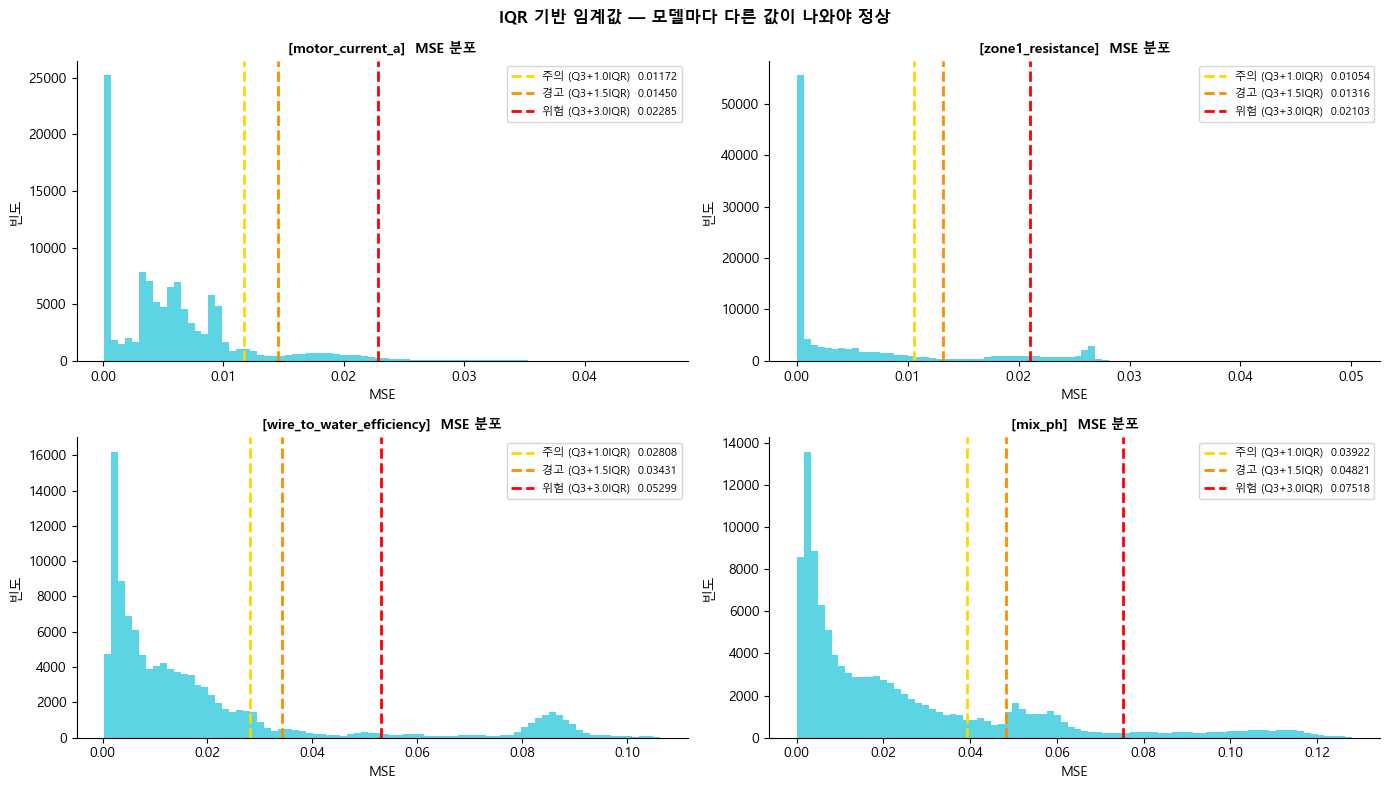

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (target, res) in enumerate(ae_results.items()):
    ax  = axes[i]
    mse = res["mse"]
    # 시각화 범위: 99.5th percentile 이하만
    xlim = np.percentile(mse, 99.5)
    ax.hist(mse[mse <= xlim], bins=80, color="#26C6DA", edgecolor="none", alpha=0.75)
    for thr, color, label in [
        (res["thr_c"], "gold",       "주의 (Q3+1.0IQR)"),
        (res["thr_w"], "darkorange", "경고 (Q3+1.5IQR)"),
        (res["thr_e"], "red",        "위험 (Q3+3.0IQR)"),
    ]:
        if thr <= xlim:
            ax.axvline(thr, color=color, lw=2, linestyle="--", label=f"{label}  {thr:.5f}")
    ax.set_title(f"[{target}]  MSE 분포", fontsize=10, fontweight="bold")
    ax.set_xlabel("MSE"); ax.set_ylabel("빈도")
    ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("IQR 기반 임계값 — 모델마다 다른 값이 나와야 정상", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

---
## Part 3 — 종합 가설 검증

| 검정 | 그룹 | 목적 |
|---|---|---|
| **t-test** | 정상 vs 이상 (정규분포 확인된 변수만) | 모수적 평균 비교 |
| **Mann-Whitney U** | 정상 vs 이상 (전체) + **Bonferroni** | 비모수, 기본 검정 |
| **Kruskal-Wallis** | 알람 레벨 0/1/2/3 | 다중 집단 비교 |
| **카이제곱** | 알람 레벨 × 피처 분위 | 독립성 검정 |
| **KS 2-sample** | 정상 vs 이상 분포 형태 비교 | 분포 전체 차이 |

In [18]:
hyp_rows = []

for target, res in ae_results.items():
    stat_cols  = [target] + TARGET_DICTIONARY[target]
    n_tests    = len(stat_cols)
    bonf_thr   = 0.05 / n_tests  # [BUG FIX 3] Bonferroni

    normal_mask  = ~res["is_anomaly"]
    anomaly_mask =  res["is_anomaly"]

    for col in stat_cols:
        v_n = df_active.loc[normal_mask,  col].dropna()
        v_a = df_active.loc[anomaly_mask, col].dropna()
        if len(v_n) < 10 or len(v_a) < 10: continue

        # Mann-Whitney U (항상 실행)
        mw_stat, mw_p = mannwhitneyu(v_n, v_a, alternative="two-sided")
        effect_r = abs(1 - 2*mw_stat / (len(v_n)*len(v_a)))

        # t-test (정규분포 확인된 변수만)
        is_norm = col in normal_cols
        if is_norm:
            tt_stat, tt_p = ttest_ind(v_n, v_a, equal_var=False)
        else:
            tt_p = np.nan

        # KS 2-sample (분포 형태 비교)
        ks_s, ks_p = ks_2samp(v_n.sample(min(3000,len(v_n)), random_state=0),
                               v_a.sample(min(3000,len(v_a)), random_state=0))

        med_n, med_a = v_n.median(), v_a.median()
        change = (med_a - med_n) / (abs(med_n) + 1e-9) * 100

        hyp_rows.append({
            "AE 모델"       : target,
            "변수"          : col,
            "정상 중앙값"   : round(med_n, 4),
            "이상 중앙값"   : round(med_a, 4),
            "변화율(%)"     : round(change, 1),
            "MWU p"         : round(mw_p, 6),
            "t-test p"      : round(tt_p, 6) if not np.isnan(tt_p) else "비정규",
            "KS p"          : round(ks_p, 6),
            "효과크기 r"    : round(effect_r, 3),
            "Bonferroni 기준": round(bonf_thr, 5),
            "유의(MWU)"     : "V" if mw_p < bonf_thr else "X",
        })

hyp_df = pd.DataFrame(hyp_rows)
print(f"[BUG FIX 3] Bonferroni 적용  (각 모델별 0.05 / n_features)")
print(f"유의한 변수: {(hyp_df['유의(MWU)']=='V').sum()} / {len(hyp_df)}")
print()
print(hyp_df.to_string(index=False))

[BUG FIX 3] Bonferroni 적용  (각 모델별 0.05 / n_features)
유의한 변수: 17 / 17

                   AE 모델                       변수    정상 중앙값   이상 중앙값  변화율(%)    MWU p t-test p    KS p  효과크기 r  Bonferroni 기준 유의(MWU)
         motor_current_a          motor_current_a    6.2220   0.0830   -98.7 0.000000      비정규 0.00000   0.596        0.01250       V
         motor_current_a      motor_temperature_c   45.2380  47.6880     5.4 0.000000      비정규 0.00000   0.462        0.01250       V
         motor_current_a                 pump_rpm 1725.6135   0.9690   -99.9 0.000000      비정규 0.00000   0.603        0.01250       V
         motor_current_a   discharge_pressure_kpa  185.6100   3.0380   -98.4 0.000000      비정규 0.00000   0.593        0.01250       V
        zone1_resistance         zone1_resistance   56.6698  47.0805   -16.9 0.000000      비정규 0.00000   0.043        0.01667       V
        zone1_resistance       zone1_pressure_kpa    2.6680 175.1180  6463.6 0.000000      비정규 0.00000   0.909        0.01667 

In [19]:
# Kruskal-Wallis: 4단계 알람 레벨 간 차이 검정
kw_rows = []

for target, res in ae_results.items():
    alarm = res["alarm"]
    stat_cols = [target] + TARGET_DICTIONARY[target]

    for col in stat_cols:
        groups = [df_active.loc[alarm==lvl, col].dropna() for lvl in [0,1,2,3]]
        groups = [g for g in groups if len(g) >= 5]
        if len(groups) < 2: continue

        kw_stat, kw_p = kruskal(*groups)
        medians = {lvl: round(df_active.loc[alarm==lvl, col].median(), 4)
                   for lvl in [0,1,2,3] if (alarm==lvl).sum() >= 5}

        kw_rows.append({
            "AE 모델"       : target,
            "변수"          : col,
            "KW statistic"  : round(kw_stat, 2),
            "p-value"       : round(kw_p, 6),
            "그룹간 차이"   : "V" if kw_p < 0.05 else "X",
            "레벨0(정상)"   : medians.get(0, "-"),
            "레벨1(주의)"   : medians.get(1, "-"),
            "레벨2(경고)"   : medians.get(2, "-"),
            "레벨3(위험)"   : medians.get(3, "-"),
        })

kw_df = pd.DataFrame(kw_rows)
print("Kruskal-Wallis: 4단계 알람 레벨 간 차이")
print(kw_df.to_string(index=False))

Kruskal-Wallis: 4단계 알람 레벨 간 차이
                   AE 모델                       변수  KW statistic  p-value 그룹간 차이   레벨0(정상)   레벨1(주의)  레벨2(경고)  레벨3(위험)
         motor_current_a          motor_current_a      11582.64 0.000000      V    6.1970    9.2000   0.0810   0.0920
         motor_current_a      motor_temperature_c      11698.78 0.000000      V   45.1140   50.9560  47.6530  47.9630
         motor_current_a                 pump_rpm      10841.43 0.000000      V 1725.1015 1758.2500   0.8600   1.5050
         motor_current_a   discharge_pressure_kpa      11460.42 0.000000      V  185.1390  240.5935   3.0200   3.1470
        zone1_resistance         zone1_resistance       1093.70 0.000000      V   63.1496   38.4357  53.5694  43.9678
        zone1_resistance       zone1_pressure_kpa      44426.88 0.000000      V    2.3880  168.2295 172.8060 177.7210
        zone1_resistance         zone1_flow_l_min       1674.99 0.000000      V    0.0310    4.4005   3.2150   4.0360
wire_to_water_efficiency 

In [20]:
# 카이제곱: 알람 레벨 x 피처 분위 독립성 검정
chi_rows = []

for target, res in ae_results.items():
    alarm = res["alarm"]
    for col in [target] + TARGET_DICTIONARY[target]:
        data = df_active[col].dropna()
        if len(data) < 100: continue

        # 피처를 3분위(Low/Mid/High)로 구간화
        try:
            binned = pd.qcut(data, q=3, labels=["Low","Mid","High"], duplicates="drop")
        except Exception:
            continue

        ct = pd.crosstab(pd.Series(alarm[data.index], name="alarm"),
                         pd.Series(binned, name="level"))
        if ct.shape[0] < 2 or ct.shape[1] < 2: continue

        chi2, p, dof, _ = chi2_contingency(ct)
        chi_rows.append({
            "AE 모델"  : target,
            "변수"     : col,
            "chi2"     : round(chi2, 2),
            "p-value"  : round(p, 6),
            "독립성 X?": "V (연관)" if p < 0.05 else "X (독립)",
        })

chi_df = pd.DataFrame(chi_rows)
print("카이제곱: 알람 레벨 x 피처 분위 독립성")
print("독립성 X = 피처 수준에 따라 알람 레벨 분포가 다름 (연관 있음)")
print()
print(chi_df.to_string(index=False))

카이제곱: 알람 레벨 x 피처 분위 독립성
독립성 X = 피처 수준에 따라 알람 레벨 분포가 다름 (연관 있음)

                   AE 모델                       변수     chi2  p-value 독립성 X?
         motor_current_a          motor_current_a 11608.80      0.0 V (연관)
         motor_current_a      motor_temperature_c 22662.19      0.0 V (연관)
         motor_current_a                 pump_rpm 11456.14      0.0 V (연관)
         motor_current_a   discharge_pressure_kpa 11295.99      0.0 V (연관)
        zone1_resistance         zone1_resistance 39589.98      0.0 V (연관)
        zone1_resistance       zone1_pressure_kpa 42839.30      0.0 V (연관)
        zone1_resistance         zone1_flow_l_min 33693.80      0.0 V (연관)
wire_to_water_efficiency wire_to_water_efficiency 19465.06      0.0 V (연관)
wire_to_water_efficiency                 pump_rpm 18857.74      0.0 V (연관)
wire_to_water_efficiency      motor_temperature_c 20448.08      0.0 V (연관)
wire_to_water_efficiency     suction_pressure_kpa 20063.35      0.0 V (연관)
wire_to_water_efficiency    bearing_

---
## Part 4 — 최종 결과 요약

In [21]:
print("=" * 100)
print("최종 가설 검증 요약 (MWU + Bonferroni 기준)")
print("=" * 100)

for model_name, grp in hyp_df.groupby("AE 모델", sort=False):
    res = ae_results[model_name]
    n_normal  = (~res["is_anomaly"]).sum()
    n_anomaly =   res["is_anomaly"].sum()
    pct = n_anomaly / len(res["is_anomaly"]) * 100

    print(f"\n[{model_name}]  "
          f"정상: {n_normal:,}개  이상: {n_anomaly:,}개 ({pct:.1f}%)  "
          f"Bonferroni 기준: {grp['Bonferroni 기준'].iloc[0]:.5f}")

    show = grp[["변수","정상 중앙값","이상 중앙값","변화율(%)","MWU p","효과크기 r","유의(MWU)"]].copy()
    print(show.to_string(index=False))

print()
print("=" * 100)
sig = hyp_df[hyp_df["유의(MWU)"] == "V"]
print(f"유의미한 변수 합계: {len(sig)} / {len(hyp_df)}")
print()
print("유의하면서 효과 크기 0.3 이상인 변수 (실질적으로 의미 있는 것):")
strong = sig[sig["효과크기 r"] >= 0.3]
if len(strong) > 0:
    print(strong[["AE 모델","변수","변화율(%)","효과크기 r","MWU p"]].to_string(index=False))
else:
    print("없음 (효과 크기 기준 완화 필요)")

최종 가설 검증 요약 (MWU + Bonferroni 기준)

[motor_current_a]  정상: 101,030개  이상: 10,863개 (9.7%)  Bonferroni 기준: 0.01250
                    변수    정상 중앙값  이상 중앙값  변화율(%)  MWU p  효과크기 r 유의(MWU)
       motor_current_a    6.2220   0.083   -98.7    0.0   0.596       V
   motor_temperature_c   45.2380  47.688     5.4    0.0   0.462       V
              pump_rpm 1725.6135   0.969   -99.9    0.0   0.603       V
discharge_pressure_kpa  185.6100   3.038   -98.4    0.0   0.593       V

[zone1_resistance]  정상: 91,354개  이상: 20,539개 (18.4%)  Bonferroni 기준: 0.01667
                변수  정상 중앙값   이상 중앙값  변화율(%)  MWU p  효과크기 r 유의(MWU)
  zone1_resistance 56.6698  47.0805   -16.9    0.0   0.043       V
zone1_pressure_kpa  2.6680 175.1180  6463.6    0.0   0.909       V
  zone1_flow_l_min  0.0420   3.7010  8711.9    0.0   0.096       V

[wire_to_water_efficiency]  정상: 94,434개  이상: 17,459개 (15.6%)  Bonferroni 기준: 0.01000
                      변수    정상 중앙값  이상 중앙값  변화율(%)  MWU p  효과크기 r 유의(MWU)
wire_to_water_efficienc

In [22]:
# 결과 저장
hyp_df.to_csv("hypothesis_mwu.csv",    index=False, encoding="utf-8-sig")
kw_df.to_csv("hypothesis_kruskal.csv", index=False, encoding="utf-8-sig")
drift_df.to_csv("ks_drift.csv",        index=False, encoding="utf-8-sig")
normality_df.to_csv("normality.csv",   index=False, encoding="utf-8-sig")

# alarm 컬럼 추가 후 저장
for target, res in ae_results.items():
    df_active[f"mse_{target}"]   = res["mse"]
    df_active[f"alarm_{target}"] = res["alarm"]
df_active.to_csv("df_active_v2.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print("  hypothesis_mwu.csv     - Mann-Whitney U + Bonferroni 결과")
print("  hypothesis_kruskal.csv - Kruskal-Wallis 4단계 알람 비교")
print("  ks_drift.csv           - KS drift test 결과")
print("  normality.csv          - 정규성 검정 결과")
print("  df_active_v2.csv       - 알람 레벨 포함 전체 데이터")

저장 완료:
  hypothesis_mwu.csv     - Mann-Whitney U + Bonferroni 결과
  hypothesis_kruskal.csv - Kruskal-Wallis 4단계 알람 비교
  ks_drift.csv           - KS drift test 결과
  normality.csv          - 정규성 검정 결과
  df_active_v2.csv       - 알람 레벨 포함 전체 데이터
